# Backtest 012 — Gaussian FRAMA + Hull Butterfly Oscillator

A long-only breakout system built on **two** indicators:

* **Gaussian FRAMA (G-FRAMA | QuantEdgeB)** — a fractal-adaptive MA driven by a
  Gaussian-filtered close, wrapped in an ATR envelope
  (`LongV = FRAMA + mult·ATR` upper "blue" band, `ShortV = FRAMA − ATR`). Its
  regime state `QB` flips **+1 (blue)** once `close > LongV` and **−1 (red)**
  once `close < ShortV`.
* **Hull Butterfly Oscillator (HBO | LuxAlgo)** — `hso` = Hull convolution minus
  its time-reversed mirror, with a cumulative-mean band; discrete state `os`
  prints **+1** on a bullish turn.

**Entry (all must hold on the signal bar):**
1. G-FRAMA cloud **turns blue** — `QB` flips to +1 (`close` crosses above the blue `LongV` band).
2. Signal candle is **green with an upper wick** — `close > open` and `high > close`.
3. **HBO bullish** — `hso` crosses above zero **or** `os == +1` (strong green bar).
4. **Previous candle is bullish** — `close[-1] > open[-1]`.

**Exit:** adaptive ATR trailing-stop cross (Pearson-r scaled multiplier) **or**
the G-FRAMA cloud turning red, with a swing-low hard stop capped at `max_sl`.
Same IS/OOS + Optuna machinery as `backtest_011`.

## 0. Imports

In [55]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numba as nb
import vectorbt as vbt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import talib
ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
# Numba disk cache from the FastAPI runtime stores module paths as `app.*`.
sys.path.insert(0, str(ROOT / 'backend'))
import backend.app
import backend.app.services
import backend.app.services.indicators
sys.modules.setdefault('app', backend.app)
sys.modules.setdefault('app.services', backend.app.services)
sys.modules.setdefault('app.services.indicators', backend.app.services.indicators)
from backend.app.services.indicators.trailing_sl import (
    atr_trailing_adaptive_nb, pearson_r_2d,
)
from backend.app.services.indicators.common import shift_2d
from backend.app.services.indicators.gaussian_frama import gaussian_frama
from backend.app.services.indicators.hull_butterfly import hull_butterfly

plt.style.use('dark_background')
print('imports ok')

imports ok


## 1. Load Data

In [56]:
from backend.app.services.data_loader import load_stocks

BENCHMARK = 'VNINDEX'
DATA_START = '2019-01-01'

df_raw = load_stocks(refresh=False)
df_raw = df_raw.loc[DATA_START:]

open_  = df_raw['open']
high   = df_raw['high']
low    = df_raw['low']
close  = df_raw['close']
volume = df_raw['volume']

valid_syms = close.columns[close.isna().mean() < 0.2]
close  = close[valid_syms].ffill()
high   = high[valid_syms].ffill()
low    = low[valid_syms].ffill()
open_  = open_[valid_syms].ffill()
volume = volume[valid_syms].ffill().fillna(0)

if BENCHMARK in close.columns:
    bm_close  = close[BENCHMARK]
    bm_volume = volume[BENCHMARK]
else:
    bm_close  = close.mean(axis=1)
    bm_volume = volume.mean(axis=1)
    print(f'BENCHMARK {BENCHMARK!r} not found — using equal-weight index')

print(f'Shape : {close.shape}  |  {close.index[0].date()} → {close.index[-1].date()}')
print(f'Symbols: {len(valid_syms)}  |  Benchmark: {BENCHMARK}')
close.tail(3)

Loading from HDF5 cache: stocks_data_latest.h5
Shape: (2540, 1000)  |  2016-08-22 → 2026-08-21
Shape : (1946, 200)  |  2019-01-02 → 2026-08-21
Symbols: 200  |  Benchmark: VNINDEX


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-08-19,6.90,16.8,21.80,40.8,8.05,11.00,12.70,16.75,6.10,5.92,...,1726.69,63.1,10.95,24.85,1.81,62.7,24.10,14.55,56.8,7.54
2026-08-20,6.90,17.0,21.95,40.9,8.15,11.00,12.75,16.70,6.00,5.89,...,1734.24,64.0,10.90,24.90,1.76,63.5,24.15,14.30,55.2,7.51
2026-08-21,7.12,17.0,22.75,41.5,8.23,11.05,13.30,17.15,5.96,5.90,...,1768.12,63.8,11.25,25.70,1.82,65.0,25.30,15.30,54.6,7.65


In [57]:
IS_FRAC   = 0.6
split_idx = int(len(close) * IS_FRAC)
oos_start = close.index[split_idx]

close_is   = close.iloc[:split_idx];  close_oos  = close.iloc[split_idx:]
high_is    = high.iloc[:split_idx];   high_oos   = high.iloc[split_idx:]
low_is     = low.iloc[:split_idx];    low_oos    = low.iloc[split_idx:]
open_is    = open_.iloc[:split_idx];  open_oos   = open_.iloc[split_idx:]
volume_is  = volume.iloc[:split_idx]; volume_oos = volume.iloc[split_idx:]

print(f'IS  {close_is.index[0].date()} → {close_is.index[-1].date()}  ({len(close_is)} bars)')
print(f'OOS {close_oos.index[0].date()} → {close_oos.index[-1].date()}  ({len(close_oos)} bars)')

IS  2019-01-02 → 2023-09-05  (1167 bars)
OOS 2023-09-06 → 2026-08-21  (779 bars)


## 2. Signal & Exit Helpers

`compute_signals` builds the 4-condition long entry from the G-FRAMA regime and
the Hull Butterfly Oscillator. `compute_exits` reuses the `backtest_011`
Pearson-r adaptive ATR trailing stop and OR-s in a "cloud turns red" exit.

In [58]:
def _sharpe_mean(pf):
    """Mean Sharpe with inf (zero-downside symbols) dropped."""
    import numpy as _np
    return pf.sharpe_ratio().replace([_np.inf, -_np.inf], _np.nan).dropna().mean()

def compute_signals(
    close, high, low, open_, volume,
    # ── Gaussian FRAMA ──
    gaussian_length: int   = 4,
    sigma:           float = 2.0,
    fm_len:          int   = 20,
    upper_limit:     int   = 8,
    lower_limit:     int   = 40,
    gframa_atr_period: int = 14,
    gframa_atr_mult: float = 1.9,
    # ── Hull Butterfly Oscillator ──
    hbo_length:      int   = 14,
    hbo_mult:        float = 2.0,
):
    """Long entries where the G-FRAMA cloud turns blue on a green upper-wick
    candle, the HBO is bullish, and the prior candle was bullish."""
    close_np = close.to_numpy().astype(np.float64)
    high_np  = high.to_numpy().astype(np.float64)
    low_np   = low.to_numpy().astype(np.float64)
    open_np  = open_.to_numpy().astype(np.float64)

    g = gaussian_frama(
        close_np, high_np, low_np,
        gaussian_length=gaussian_length, sigma=sigma,
        fm_len=fm_len, upper_limit=upper_limit, lower_limit=lower_limit,
        atr_period=gframa_atr_period, atr_mult=gframa_atr_mult,
    )
    qb     = g['qb']
    long_v = g['long_v']

    hso, os = hull_butterfly(close_np, length=hbo_length, mult=hbo_mult)

    # 1) cloud turns blue: QB flips to +1
    qb_prev          = shift_2d(qb, 1)
    cloud_turns_blue = (qb == 1.0) & (qb_prev != 1.0)

    # 2) green candle with an upper wick, closing above the blue band
    green_candle = close_np > open_np
    upper_wick   = high_np > close_np
    above_band   = close_np > long_v

    # 3) HBO bullish: hso crosses above 0, or a strong green bar (os == +1)
    # hso_prev = shift_2d(hso, 1)
    # hbo_bull = ((hso > 0.0) & (hso_prev <= 0.0)) | (os == 1.0)
    hbo_bull = hso > 0.0

    # 4) previous candle bullish
    prev_bull = shift_2d(green_candle.astype(np.float64), 1) > 0.0

    entries_np = (
        cloud_turns_blue 
        # & green_candle & upper_wick
        & above_band & hbo_bull 
        # & prev_bull
    )
    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(
    open_, close, high, low, volume,
    atr_period:        int   = 10,
    low_stop_lookback: int   = 5,
    max_sl:            float = 0.10,
    atr_mult_min:      float = 1.5,
    atr_mult_max:      float = 3.5,
    corr_window:       int   = 20,
    r_smooth:          int   = 1,
    # ── G-FRAMA cloud-red exit (same bands as entry) ──
    use_gframa_exit:   bool  = False,
    gaussian_length:   int   = 4,
    sigma:             float = 2.0,
    fm_len:            int   = 20,
    upper_limit:       int   = 8,
    lower_limit:       int   = 40,
    gframa_atr_period: int   = 14,
    gframa_atr_mult:   float = 1.9,
):
    """Returns (exits_df, sl_stop_df).

    exits_df   : Pearson-r adaptive ATR trailing-stop crossings, OR-ed with the
                 G-FRAMA cloud flipping to red (QB -> -1).
    sl_stop_df : per-bar swing-low relative stop, hard-capped at max_sl.
    """
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=atr_period
    )
    try:
        close_np = close.to_numpy().astype(np.float64)
        atr_np   = atr_raw.real.to_numpy().astype(np.float64)

        r_np = pearson_r_2d(close_np, corr_window)
        if r_smooth and r_smooth > 1:
            r_np = (pd.DataFrame(r_np, index=close.index, columns=close.columns)
                    .ewm(span=r_smooth, adjust=False).mean().to_numpy())
        lin     = np.clip(np.nan_to_num(r_np, nan=0.0), 0.0, 1.0)
        mult_np = atr_mult_min + (atr_mult_max - atr_mult_min) * lin

        trail_np = atr_trailing_adaptive_nb(close_np, atr_np, mult_np)
        atr_sl   = pd.DataFrame(trail_np, index=close.index, columns=close.columns)
        exits_df = close.vbt.crossed_below(atr_sl)

        if use_gframa_exit:
            g = gaussian_frama(
                close_np,
                high.to_numpy().astype(np.float64),
                low.to_numpy().astype(np.float64),
                gaussian_length=gaussian_length, sigma=sigma,
                fm_len=fm_len, upper_limit=upper_limit, lower_limit=lower_limit,
                atr_period=gframa_atr_period, atr_mult=gframa_atr_mult,
            )
            qb        = g['qb']
            qb_prev   = shift_2d(qb, 1)
            cloud_red = pd.DataFrame(
                (qb == -1.0) & (qb_prev != -1.0),
                index=close.index, columns=close.columns,
            )
            exits_df = exits_df | cloud_red

        MIN        = vbt.IndicatorFactory.from_talib('MIN')
        lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
        sl_stop_df = ((close - lowest_low) / close).clip(lower=0, upper=max_sl)
    except Exception as e:
        print(e)
        empty = pd.DataFrame(False, index=close.index, columns=close.columns)
        return empty, empty

    return exits_df, sl_stop_df


print('Signal functions defined')

Signal functions defined


## 3. Baseline Run (default params)

In [59]:
# VNINDEX Buy & Hold — full-sample reference
bm_entries_full = pd.DataFrame(False, index=close.index, columns=[BENCHMARK])
bm_entries_full.iloc[0, 0] = True
bm_exits_full   = pd.DataFrame(False, index=close.index, columns=[BENCHMARK])

pf_bh_full = vbt.Portfolio.from_signals(
    close=close[[BENCHMARK]], entries=bm_entries_full, exits=bm_exits_full,
    freq='1d', group_by=['symbol'], cash_sharing=False, init_cash=100,
)
bh_total  = float(pf_bh_full.total_return())
bh_sharpe = float(pf_bh_full.sharpe_ratio())
print(f'VNINDEX Buy & Hold (full)  Total Return={bh_total:.1%}  Sharpe={bh_sharpe:.3f}')

VNINDEX Buy & Hold (full)  Total Return=98.3%  Sharpe=0.670


In [60]:
# Default-param run on the full sample (sanity check)
entries0 = compute_signals(close, high, low, open_, volume)
exits0, sl0 = compute_exits(open_, close, high, low, volume)

pf0 = vbt.Portfolio.from_signals(
    close=close, entries=entries0, exits=exits0,
    freq='1d', group_by=['symbol'], cash_sharing=False, sl_stop=sl0,
)
print(f'Entries/sym (mean): {entries0.sum().mean():.1f}   total signals: {int(entries0.values.sum())}')
print(f'Default  mean Total Return={pf0.total_return().mean():.1%}  mean Sharpe={_sharpe_mean(pf0):.3f}')

Entries/sym (mean): 23.9   total signals: 4782
Default  mean Total Return=168.3%  mean Sharpe=0.583


## 4. Optimisation (Optuna, multi-objective)

One NSGA-II study over the G-FRAMA + HBO + exit parameters, maximising
(mean Total Return %, mean Sortino) across the IS symbols.

In [61]:
def objective(trial):
    # ── Gaussian FRAMA ──
    gaussian_length   = trial.suggest_int  ('gaussian_length',   2, 10)
    sigma             = trial.suggest_float('sigma',             1.0, 4.0, step=0.5)
    fm_len            = trial.suggest_int  ('fm_len',            10, 30, step=2)
    gframa_atr_period = trial.suggest_int  ('gframa_atr_period', 5, 20)
    gframa_atr_mult   = trial.suggest_float('gframa_atr_mult',   1.0, 3.0, step=0.1)
    # ── Hull Butterfly ──
    hbo_length        = trial.suggest_int  ('hbo_length',        8, 24)
    hbo_mult          = trial.suggest_float('hbo_mult',          1.0, 3.0, step=0.25)
    # ── exit ──
    low_stop_lookback = trial.suggest_int  ('low_stop_lookback', 2, 5)
    atr_period        = trial.suggest_int  ('atr_period',        5, 20)
    atr_mult_min      = trial.suggest_float('atr_mult_min',      1.0, 2.5, step=0.1)
    atr_mult_max      = trial.suggest_float('atr_mult_max',      atr_mult_min + 0.5, 4.0, step=0.1)
    corr_window       = trial.suggest_int  ('corr_window',       10, 40, step=5)
    max_sl            = trial.suggest_float('max_sl',            0.04, 0.15, step=0.01)

    try:
        entries = compute_signals(
            close_is, high_is, low_is, open_is, volume_is,
            gaussian_length=gaussian_length, sigma=sigma, fm_len=fm_len,
            gframa_atr_period=gframa_atr_period, gframa_atr_mult=gframa_atr_mult,
            hbo_length=hbo_length, hbo_mult=hbo_mult,
        )
        exits, sl_stop_df = compute_exits(
            open_is, close_is, high_is, low_is, volume_is,
            atr_period=atr_period, low_stop_lookback=low_stop_lookback,
            max_sl=max_sl, atr_mult_min=atr_mult_min, atr_mult_max=atr_mult_max,
            corr_window=corr_window,
            gaussian_length=gaussian_length, sigma=sigma, fm_len=fm_len,
            gframa_atr_period=gframa_atr_period, gframa_atr_mult=gframa_atr_mult,
        )
        pf = vbt.Portfolio.from_signals(
            close=close_is, entries=entries, exits=exits,
            freq='1d', group_by=['symbol'], cash_sharing=False, sl_stop=sl_stop_df,
        )
        total_ret = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
        sharpe    = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
        sortino   = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
        if len(total_ret) == 0:
            return -999.0, -999.0
        mean_ret     = float(total_ret.mean() * 100)
        mean_sortino = float(sortino.mean()) if len(sortino) > 0 else -999.0
        # penalise if <30% of symbols profitable
        if len(sharpe) > 0 and (sharpe > 0).mean() < 0.3:
            mean_ret     *= 0.5
            mean_sortino *= 0.5
        return mean_ret, mean_sortino
    except Exception:
        return -999.0, -999.0


N_TRIALS = 500   # raise for better coverage

study = optuna.create_study(
    directions=['maximize', 'maximize'],
    study_name='gframa_hbo',
    sampler=optuna.samplers.NSGAIISampler(seed=42),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'Pareto front: {len(study.best_trials)} trials')

  0%|          | 0/500 [00:00<?, ?it/s]

Pareto front: 6 trials


## 5. Select Best Params

In [62]:
SELECTION = 'balanced'   # 'best_return' | 'best_sortino' | 'balanced'

def pick_best(study, selection=SELECTION):
    if selection == 'best_return':
        return max(study.best_trials, key=lambda t: t.values[0])
    if selection == 'best_sortino':
        return max(study.best_trials, key=lambda t: t.values[1])
    def score(t):
        return 0.4 * (t.values[0] + 100) / 200 + 0.6 * (t.values[1] + 10) / 20
    return max(study.best_trials, key=score)

best_trial  = pick_best(study)
best_params = best_trial.params

summary_df = pd.Series(
    {'Trial #': best_trial.number,
     'Total Return (%)': round(best_trial.values[0], 2),
     'Sortino':          round(best_trial.values[1], 3),
     **best_trial.params},
    name='value',
).to_frame()
print(f'Selection strategy: {SELECTION}')
import json
print(json.dumps(best_params, indent=2, default=str))
display(summary_df)

Selection strategy: balanced
{
  "gaussian_length": 6,
  "sigma": 1.0,
  "fm_len": 16,
  "gframa_atr_period": 5,
  "gframa_atr_mult": 1.0,
  "hbo_length": 8,
  "hbo_mult": 2.25,
  "low_stop_lookback": 5,
  "atr_period": 7,
  "atr_mult_min": 2.5,
  "atr_mult_max": 3.7,
  "corr_window": 20,
  "max_sl": 0.13
}


,value
Trial #,441.000
Total Return (%),249.610
Sortino,1.498
gaussian_length,6.000
sigma,1.000
fm_len,16.000
gframa_atr_period,5.000
gframa_atr_mult,1.000
hbo_length,8.000
hbo_mult,2.250


## 6. Final Backtest — Optimised params on OOS

In [63]:
# ── VNINDEX Buy & Hold on OOS (passive benchmark to beat) ──
bm_entries_oos = pd.DataFrame(False, index=close_oos.index, columns=[BENCHMARK])
bm_entries_oos.iloc[0, 0] = True
bm_exits_oos   = pd.DataFrame(False, index=close_oos.index, columns=[BENCHMARK])

pf_base = vbt.Portfolio.from_signals(
    close=close_oos[[BENCHMARK]], entries=bm_entries_oos, exits=bm_exits_oos,
    freq='1d', group_by=['symbol'], cash_sharing=False, init_cash=100,
)
bh_sharpe_oos = float(np.atleast_1d(pf_base.sharpe_ratio())[0])
bh_ret_oos    = float(np.atleast_1d(pf_base.total_return())[0])
print(f'VNINDEX Buy & Hold (OOS)  Total Return={bh_ret_oos:.1%}  Sharpe={bh_sharpe_oos:.3f}')

# ── Optimised params applied to OOS ──
p = best_params
entries_oos = compute_signals(
    close_oos, high_oos, low_oos, open_oos, volume_oos,
    gaussian_length=p['gaussian_length'], sigma=p['sigma'], fm_len=p['fm_len'],
    gframa_atr_period=p['gframa_atr_period'], gframa_atr_mult=p['gframa_atr_mult'],
    hbo_length=p['hbo_length'], hbo_mult=p['hbo_mult'],
)
exits_oos, sl_oos = compute_exits(
    open_oos, close_oos, high_oos, low_oos, volume_oos,
    atr_period=p['atr_period'], low_stop_lookback=p['low_stop_lookback'],
    max_sl=p['max_sl'], atr_mult_min=p['atr_mult_min'], atr_mult_max=p['atr_mult_max'],
    corr_window=p['corr_window'],
    gaussian_length=p['gaussian_length'], sigma=p['sigma'], fm_len=p['fm_len'],
    gframa_atr_period=p['gframa_atr_period'], gframa_atr_mult=p['gframa_atr_mult'],
)
pf_oos = vbt.Portfolio.from_signals(
    close=close_oos, entries=entries_oos, exits=exits_oos,
    freq='1d', group_by=['symbol'], cash_sharing=False, sl_stop=sl_oos,
)
print(f'OOS  mean Total Return={pf_oos.total_return().mean():.1%}  '
      f'mean Sharpe={_sharpe_mean(pf_oos):.3f}  '
      f'vs VNINDEX {bh_sharpe_oos:.3f}  '
      f'(Δ{_sharpe_mean(pf_oos)-bh_sharpe_oos:+.3f})')

VNINDEX Buy & Hold (OOS)  Total Return=42.0%  Sharpe=0.858
OOS  mean Total Return=26.2%  mean Sharpe=0.339  vs VNINDEX 0.858  (Δ-0.519)


## 7. Comparison — Stats

── G-FRAMA + HBO (OOS, optimised) ──
  Symbols            : 200
  Mean Total Return  : 26.2%
  Median Total Return: 5.9%
  Mean Sharpe        : 0.339
  Mean Sortino       : 0.555
  % symbols positive : 60%


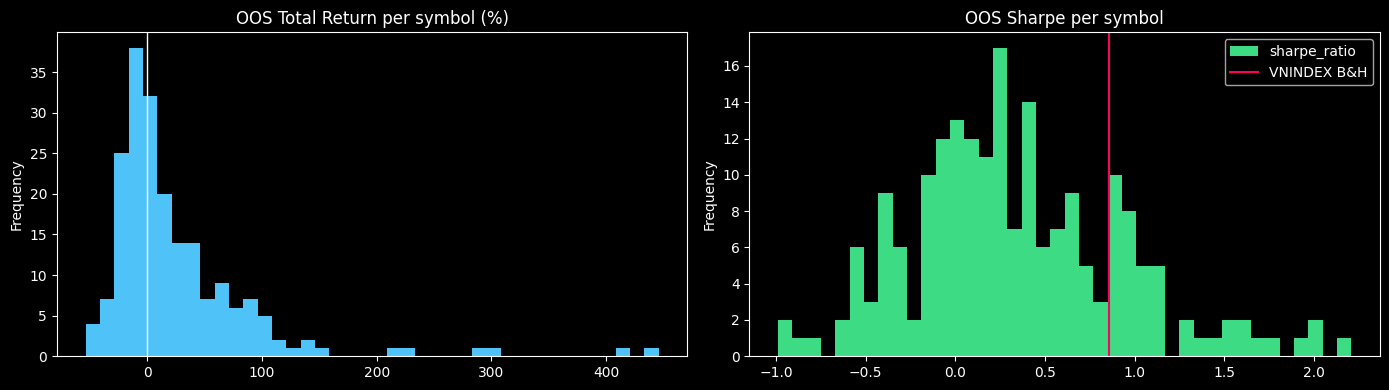

In [64]:
def _clean(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()

def show_stats(pf, label):
    tr  = _clean(pf.total_return())
    shp = _clean(pf.sharpe_ratio())
    srt = _clean(pf.sortino_ratio())
    print(f'── {label} ──')
    print(f'  Symbols            : {len(tr)}')
    print(f'  Mean Total Return  : {tr.mean():.1%}')
    print(f'  Median Total Return: {tr.median():.1%}')
    print(f'  Mean Sharpe        : {shp.mean():.3f}')
    print(f'  Mean Sortino       : {srt.mean():.3f}')
    print(f'  % symbols positive : {(tr > 0).mean():.0%}')

show_stats(pf_oos, 'G-FRAMA + HBO (OOS, optimised)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
_clean(pf_oos.total_return()).mul(100).plot.hist(bins=40, ax=axes[0], color='#4fc3f7')
axes[0].axvline(0, color='w', lw=1); axes[0].set_title('OOS Total Return per symbol (%)')
_clean(pf_oos.sharpe_ratio()).plot.hist(bins=40, ax=axes[1], color='#3ddc84')
axes[1].axvline(bh_sharpe_oos, color='#ff005d', lw=1.5, label='VNINDEX B&H')
axes[1].set_title('OOS Sharpe per symbol'); axes[1].legend()
plt.tight_layout(); plt.show()

## 7b. Static vs Default Parameters (OOS)

A hand-picked **static** parameter set, compared on the same held-out OOS slice
against the **default** signature params and the Optuna-**optimised** params.

In [65]:
# ── Static hand-picked parameter set ─────────────────────────────────────────
STATIC_PARAMS = {
    "gaussian_length": 6,
    "sigma": 1.0,
    "fm_len": 16,
    "gframa_atr_period": 5,
    "gframa_atr_mult": 1.0,
    "hbo_length": 9,
    "hbo_mult": 2.5,
    "low_stop_lookback": 5,
    "atr_period": 7,
    "atr_mult_min": 2.5,
    "atr_mult_max": 4.0,
    "corr_window": 20,
    "max_sl": 0.11,
}

# ── Default params = the compute_signals / compute_exits signature defaults ──
import inspect
def _sig_defaults(func):
    return {k: v.default for k, v in inspect.signature(func).parameters.items()
            if v.default is not inspect.Parameter.empty}
DEFAULT_PARAMS = {**_sig_defaults(compute_signals), **_sig_defaults(compute_exits)}


def build_pf_oos(p, size=None):
    """Run one parameter dict on the OOS slice -> vbt Portfolio."""
    entries = compute_signals(
        close_oos, high_oos, low_oos, open_oos, volume_oos,
        gaussian_length=p['gaussian_length'], sigma=p['sigma'], fm_len=p['fm_len'],
        gframa_atr_period=p['gframa_atr_period'], gframa_atr_mult=p['gframa_atr_mult'],
        hbo_length=p['hbo_length'], hbo_mult=p['hbo_mult'],
    )
    exits, sl = compute_exits(
        open_oos, close_oos, high_oos, low_oos, volume_oos,
        atr_period=p['atr_period'], low_stop_lookback=p['low_stop_lookback'],
        max_sl=p['max_sl'], atr_mult_min=p['atr_mult_min'], atr_mult_max=p['atr_mult_max'],
        corr_window=p['corr_window'],
        gaussian_length=p['gaussian_length'], sigma=p['sigma'], fm_len=p['fm_len'],
        gframa_atr_period=p['gframa_atr_period'], gframa_atr_mult=p['gframa_atr_mult'],
    )
    kw = {} if size is None else dict(size=size, size_type=vbt.portfolio.enums.SizeType.Percent)
    return vbt.Portfolio.from_signals(
        close=close_oos, entries=entries, exits=exits,
        freq='1d', group_by=['symbol'], cash_sharing=False, sl_stop=sl, **kw,
    )

pf_default = build_pf_oos(DEFAULT_PARAMS)
pf_static  = build_pf_oos(STATIC_PARAMS)
# pf_oos already holds the optimised OOS run (Section 6)

def stat_row(pf, label):
    def _s(x):  # single-symbol portfolios return scalars -> coerce to Series
        return _clean(pd.Series(np.atleast_1d(x), dtype=float))
    tr  = _s(pf.total_return())
    shp = _s(pf.sharpe_ratio())
    srt = _s(pf.sortino_ratio())
    return {
        'Config':             label,
        'Symbols':            len(tr),
        'Mean Total Ret':     f'{tr.mean():.1%}',
        'Median Total Ret':   f'{tr.median():.1%}',
        'Mean Sharpe':        round(shp.mean(), 3),
        'Mean Sortino':       round(srt.mean(), 3),
        '% Positive':         f'{(tr > 0).mean():.0%}',
        'N Trades':           int(pf.trades.count().sum()),
    }

cmp_oos = pd.DataFrame([
    stat_row(pf_default, 'Default'),
    stat_row(pf_static,  'Static'),
    stat_row(pf_oos,     'Optimised'),
]).set_index('Config')

print(f'VNINDEX Buy & Hold (OOS)  Total Return={bh_ret_oos:.1%}  Sharpe={bh_sharpe_oos:.3f}')
print('=== Default vs Static vs Optimised (OOS) ===')
display(cmp_oos.T)

VNINDEX Buy & Hold (OOS)  Total Return=42.0%  Sharpe=0.858
=== Default vs Static vs Optimised (OOS) ===


Config,Default,Static,Optimised
Symbols,200,200,200
Mean Total Ret,17.3%,26.3%,26.2%
Median Total Ret,4.0%,6.1%,5.9%
Mean Sharpe,0.258,0.344,0.339
Mean Sortino,0.45,0.569,0.555
% Positive,57%,59%,60%
N Trades,1587,2266,2311


## 7c. Bond-Yield Regime Position Sizing (OOS)

Adapted from `regime_gkyz_x_bond_yield.ipynb`. A market-wide **risk-off** state
is flagged when GKYZ volatility is HIGH **and** the 10Y bond yield is rising
(the `ON·rising` quadrant). On those bars we enter new positions at reduced
capital (`LOW_W`); everywhere else at full size. The regime is computed on
VNINDEX + the 10Y yield, so it is a single per-bar scalar broadcast to every
symbol. Compared here against the same optimised params at full size.

OOS bars: 779   risk-off (ON.rising): 353 (45%)   exposure there = 30%
=== Full size vs bond-yield-scaled sizing (OOS) ===


Config,VNINDEX Buy & Hold,Optimised (full size),Optimised + bond-yield sizing
Symbols,1,200,200
Mean Total Ret,42.0%,26.2%,9.5%
Median Total Ret,42.0%,5.9%,2.7%
Mean Sharpe,0.858,0.339,0.184
Mean Sortino,1.161,0.555,0.33
% Positive,100%,60%,55%
N Trades,1,2311,2311


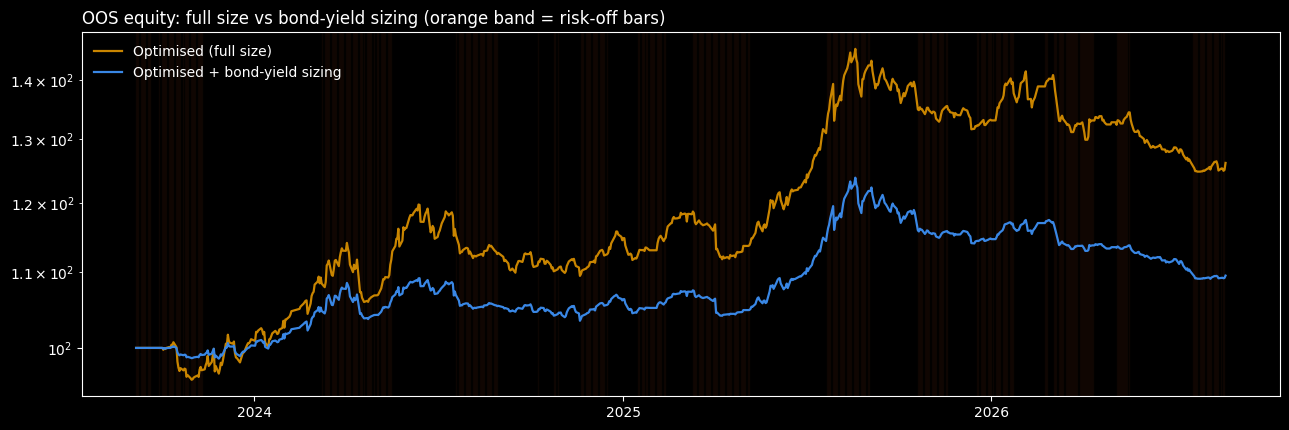

In [66]:
from backend.app.services.indicators.regime_signals import gkyz_hysteresis

# ── Bond-yield regime config (mirrors regime_gkyz_x_bond_yield.ipynb) ─────────
YIELD_SYMBOL = 'VIETNAM_10Y'   # strongest equity link in the correlation study
YIELD_WINDOW = 21              # trailing days for the yield trend
YIELD_BAND   = 0.20            # pp deadband (sticky, mirrors GKYZ hysteresis)
LOW_W        = 0.30            # exposure fraction when in the risk-off quadrant

if YIELD_SYMBOL not in df_raw['close'].columns:
    raise KeyError(
        f"{YIELD_SYMBOL!r} missing from df_raw - the notebooks-dir HDF5 cache must "
        f"include the VIETNAM_* tenors (load_stocks appends them). Refresh the cache."
    )

def yield_trend_regime(y, window=YIELD_WINDOW, band=YIELD_BAND):
    """Sticky rising/falling state: True = yields rising (equity headwind)."""
    dy = y.diff(window)
    state, out = False, []
    for v in dy.to_numpy():
        if not np.isnan(v):
            if not state and v > band:
                state = True
            elif state and v < -band:
                state = False
        out.append(state)
    return pd.Series(out, index=y.index)

# Regime inputs on the benchmark, aligned to the panel index.
bm_ohlc = pd.DataFrame({'open': open_[BENCHMARK], 'high': high[BENCHMARK],
                        'low': low[BENCHMARK], 'close': close[BENCHMARK]})
yields  = df_raw['close'][YIELD_SYMBOL].reindex(close.index).ffill(limit=5)

risk_on  = gkyz_hysteresis(bm_ohlc['open'].values, bm_ohlc['high'].values,
                           bm_ohlc['low'].values, bm_ohlc['close'].values,
                           index=close.index)          # True = HIGH vol
rates_up = yield_trend_regime(yields)                  # True = rising yields

# Surgical rule: cut exposure ONLY in ON.rising (high vol + rising yields).
risk_off_mask = (risk_on & rates_up)
regime_w = pd.Series(np.where(risk_off_mask, LOW_W, 1.0), index=close.index)

# Broadcast the per-bar scalar to (bars x symbols) and slice to OOS.
size_full = pd.DataFrame(
    np.repeat(regime_w.to_numpy()[:, None], close.shape[1], axis=1),
    index=close.index, columns=close.columns,
)
size_oos = size_full.loc[close_oos.index]

oos_off = risk_off_mask.loc[close_oos.index]
print(f'OOS bars: {len(oos_off)}   risk-off (ON.rising): {int(oos_off.sum())} '
      f'({oos_off.mean():.0%})   exposure there = {LOW_W:.0%}')

# ── Optimised params: full size vs bond-yield sized (OOS) ────────────────────
pf_opt_full  = pf_oos                              # Section 6 (default size = 100%)
pf_opt_sized = build_pf_oos(best_params, size=size_oos)

cmp_size = pd.DataFrame([
    stat_row(pf_base,       'VNINDEX Buy & Hold'),
    stat_row(pf_opt_full,   'Optimised (full size)'),
    stat_row(pf_opt_sized,  'Optimised + bond-yield sizing'),
]).set_index('Config')
print('=== Full size vs bond-yield-scaled sizing (OOS) ===')
display(cmp_size.T)

# ── Aggregate equity curves (sum of per-symbol value) ────────────────────────
fig, ax = plt.subplots(figsize=(13, 4.4))
for pf, c, lbl in [(pf_opt_full,  '#c98500', 'Optimised (full size)'),
                   (pf_opt_sized, '#3987e5', 'Optimised + bond-yield sizing')]:
    eq = pf.value().sum(axis=1)
    ax.plot(eq.index, eq / eq.iloc[0] * 100, color=c, linewidth=1.6, label=lbl)
# shade the risk-off (reduced-exposure) OOS bars
for d in oos_off.index[oos_off.to_numpy()]:
    ax.axvspan(d, d, color='#d95926', alpha=0.06)
ax.set_yscale('log'); ax.set_title('OOS equity: full size vs bond-yield sizing '
                                    '(orange band = risk-off bars)', loc='left')
ax.legend(frameon=False, loc='upper left')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()

## 8. Strategy Visualization

3-panel dark chart mirroring the `backtest_011` style:
* **Panel 1** — Close + G-FRAMA cloud (blue when `QB=+1`, red when `QB=-1`),
  the FRAMA line, the adaptive ATR trailing stop, and the actual vectorbt
  entry (^) / exit (v) bars.
* **Panel 2** — Hull Butterfly Oscillator `hso` (4-colour) with ±`cmean`
  bands and `os=+1` strong-green-bar markers.
* **Panel 3** — Pearson r that drives the adaptive ATR multiplier.

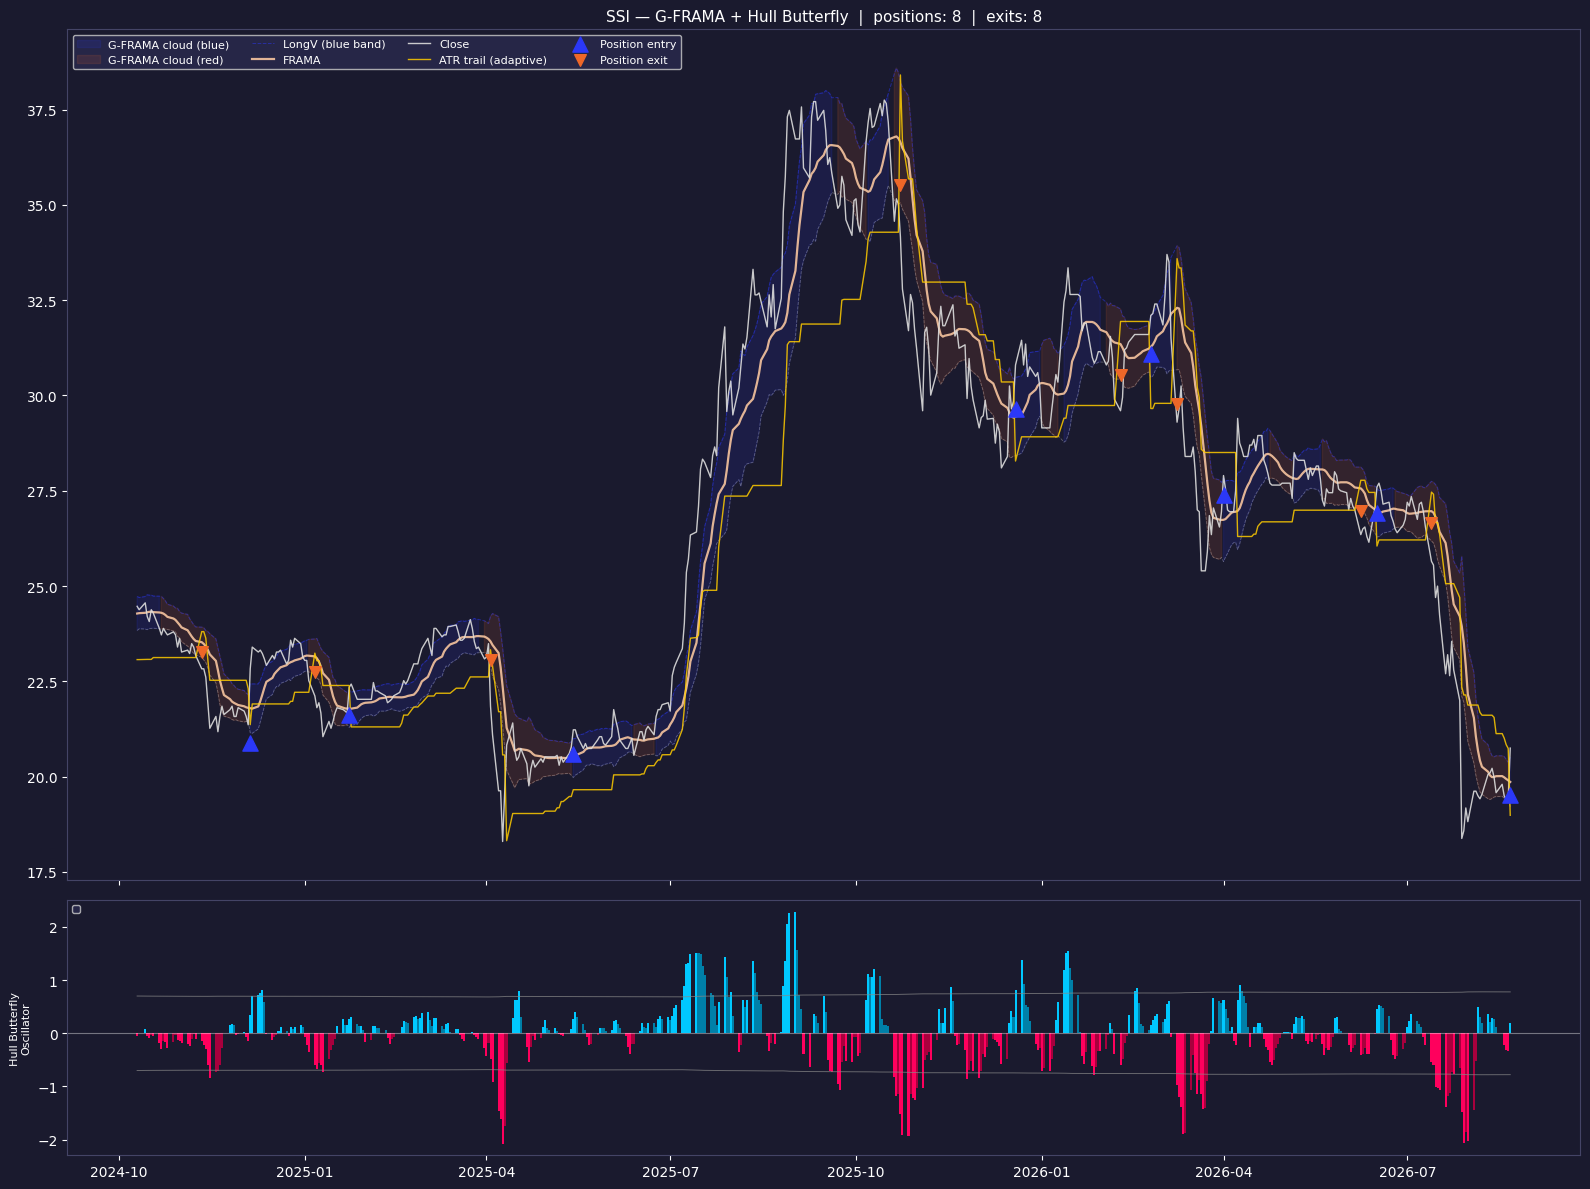


SSI — Latest readings:
  Close      : 20.75
  FRAMA      : 19.86   LongV(blue) 20.51   ShortV 19.21
  G-FRAMA    : BLUE 🔵
  HBO hso    : +0.199   cmean ±0.779   os +0
  Pearson r  : +0.167   ->   ATR mult 2.70
  ATR trail  : 18.99
  SSI — G-FRAMA + HBO performance (vectorbt)
  Total Return : 397.51%
  Sharpe       : 1.046
  Sortino      : 1.628
  Max Drawdown : -31.74%
  # Trades     : 33
  Win Rate     : 39.39%


In [76]:
# ── G-FRAMA + Hull Butterfly — Strategy Visualization ────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")
import talib as _ta

LOOKBACK = 504            # bars to show (None = all)
R_SMOOTH = 1              # EMA span on r for the trail (1 = off), matches compute_exits default

# Pull tuned params if a study has run, else the compute_signals/exits defaults.
try:
    _p = best_params
except NameError:
    _p = {}
P = dict(
    gaussian_length   = _p.get('gaussian_length',   4),
    sigma             = _p.get('sigma',              2.0),
    fm_len            = _p.get('fm_len',             20),
    upper_limit       = _p.get('upper_limit',        8),
    lower_limit       = _p.get('lower_limit',        40),
    gframa_atr_period = _p.get('gframa_atr_period',  14),
    gframa_atr_mult   = _p.get('gframa_atr_mult',    1.9),
    hbo_length        = _p.get('hbo_length',         14),
    hbo_mult          = _p.get('hbo_mult',           2.0),
    atr_period        = _p.get('atr_period',         10),
    atr_mult_min      = _p.get('atr_mult_min',       1.5),
    atr_mult_max      = _p.get('atr_mult_max',       3.5),
    corr_window       = _p.get('corr_window',        20),
    low_stop_lookback = _p.get('low_stop_lookback',  5),
    max_sl            = _p.get('max_sl',             0.10),
)

BULL_C, BEAR_C, DARK = '#2B38F7', '#ee6728', '#1a1a2e'
FRAMA_C = '#f7c59f'


def display_gframa_hbo(symbol):
    c1, h1, l1 = close[[symbol]], high[[symbol]], low[[symbol]]
    o1, v1     = open_[[symbol]], volume[[symbol]]
    cN = c1.to_numpy().astype(np.float64)          # (n, 1)
    hN = h1.to_numpy().ravel().astype(np.float64)
    lN = l1.to_numpy().ravel().astype(np.float64)
    oN = o1.to_numpy().ravel().astype(np.float64)
    cc = cN.ravel()

    # ── Gaussian FRAMA cloud ─────────────────────────────────────────────────
    g       = gaussian_frama(
        cN, h1.to_numpy().astype(np.float64), l1.to_numpy().astype(np.float64),
        gaussian_length=P['gaussian_length'], sigma=P['sigma'], fm_len=P['fm_len'],
        upper_limit=P['upper_limit'], lower_limit=P['lower_limit'],
        atr_period=P['gframa_atr_period'], atr_mult=P['gframa_atr_mult'],
    )
    frama   = g['frama'].ravel()
    long_v  = g['long_v'].ravel()
    short_v = g['short_v'].ravel()
    qb      = g['qb'].ravel()

    # ── Hull Butterfly Oscillator + cumulative-mean band ─────────────────────
    hso, os = hull_butterfly(cN, length=P['hbo_length'], mult=P['hbo_mult'])
    hso, os = hso.ravel(), os.ravel()
    _valid  = ~np.isnan(hso)
    _cnt    = np.cumsum(_valid)
    _cumabs = np.nancumsum(np.abs(hso))
    cmean   = np.where(_cnt > 0, _cumabs / np.maximum(_cnt, 1) * P['hbo_mult'], np.nan)

    # ── Pearson r → adaptive ATR trailing stop ───────────────────────────────
    r = pearson_r_2d(cN, P['corr_window']).ravel()
    if R_SMOOTH and R_SMOOTH > 1:
        r = pd.Series(r, index=c1.index).ewm(span=R_SMOOTH, adjust=False).mean().to_numpy()
    lin   = np.clip(np.nan_to_num(r, nan=0.0), 0.0, 1.0)
    mult  = P['atr_mult_min'] + (P['atr_mult_max'] - P['atr_mult_min']) * lin
    atr_p = _ta.ATR(hN, lN, cc, timeperiod=P['atr_period'])
    trail = atr_trailing_adaptive_nb(cN, atr_p.reshape(-1, 1), mult.reshape(-1, 1)).ravel()

    # ── entry / exit signals via the real strategy functions ─────────────────
    entries_df = compute_signals(
        c1, h1, l1, o1, v1,
        gaussian_length=P['gaussian_length'], sigma=P['sigma'], fm_len=P['fm_len'],
        upper_limit=P['upper_limit'], lower_limit=P['lower_limit'],
        gframa_atr_period=P['gframa_atr_period'], gframa_atr_mult=P['gframa_atr_mult'],
        hbo_length=P['hbo_length'], hbo_mult=P['hbo_mult'],
    )
    exits_df, sl_stop_df = compute_exits(
        o1, c1, h1, l1, v1,
        atr_period=P['atr_period'], low_stop_lookback=P['low_stop_lookback'],
        max_sl=P['max_sl'], atr_mult_min=P['atr_mult_min'],
        atr_mult_max=P['atr_mult_max'], corr_window=P['corr_window'],
        gaussian_length=P['gaussian_length'], sigma=P['sigma'], fm_len=P['fm_len'],
        upper_limit=P['upper_limit'], lower_limit=P['lower_limit'],
        gframa_atr_period=P['gframa_atr_period'], gframa_atr_mult=P['gframa_atr_mult'],
    )

    # ── actual vectorbt positions (one-at-a-time entry + sl_stop) ─────────────
    pf_sym = vbt.Portfolio.from_signals(
        close=c1, entries=entries_df, exits=exits_df,
        freq='1d', group_by=['symbol'], cash_sharing=False, sl_stop=sl_stop_df,
    )
    _rec        = pf_sym.trades.records
    pos_entry_i = np.asarray(_rec['entry_idx'], dtype=int)
    _closed     = np.asarray(_rec['status'], dtype=int) == 1
    pos_exit_i  = np.asarray(_rec['exit_idx'], dtype=int)[_closed]
    n_full      = len(cc)

    # ── slice to LOOKBACK ────────────────────────────────────────────────────
    s   = slice(-LOOKBACK, None) if LOOKBACK else slice(None)
    idx = c1.index[s]
    (cc, frama, long_v, short_v, qb, hso, os, cmean, r,
     trail, hN, lN, oN) = [a[s] for a in (
        cc, frama, long_v, short_v, qb, hso, os, cmean, r,
        trail, hN, lN, oN)]

    _off        = n_full - len(cc)
    pos_entry_i = pos_entry_i - _off
    pos_exit_i  = pos_exit_i  - _off
    pos_entry_i = pos_entry_i[(pos_entry_i >= 0) & (pos_entry_i < len(cc))]
    pos_exit_i  = pos_exit_i[(pos_exit_i  >= 0) & (pos_exit_i  < len(cc))]

    # ── plot ─────────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True,
        gridspec_kw={'height_ratios': [4, 1.2]})
    fig.patch.set_facecolor(DARK)
    for ax in (ax1, ax2):
        ax.set_facecolor(DARK)
        for sp in ax.spines.values(): sp.set_color('#444466')
        ax.tick_params(colors='white')

    # Panel 1 — price + G-FRAMA cloud + signals
    blue_mask = qb == 1.0
    red_mask  = qb == -1.0
    ax1.fill_between(idx, long_v, short_v, where=blue_mask, color=BULL_C, alpha=0.12,
                     interpolate=False, label='G-FRAMA cloud (blue)')
    ax1.fill_between(idx, long_v, short_v, where=red_mask, color=BEAR_C, alpha=0.12,
                     interpolate=False, label='G-FRAMA cloud (red)')
    ax1.plot(idx, long_v,  color=BULL_C, lw=0.7, alpha=0.5, ls='--', label='LongV (blue band)')
    ax1.plot(idx, short_v, color='white', lw=0.6, alpha=0.3, ls='--')
    ax1.plot(idx, frama,   color=FRAMA_C, lw=1.6, alpha=0.9, label='FRAMA')
    ax1.plot(idx, cc,      color='#dddddd', lw=1.0, alpha=0.9, label='Close')
    ax1.plot(idx, trail,   color='#ffcc00', lw=1.0, alpha=0.85, label='ATR trail (adaptive)')

    e_i, x_i = pos_entry_i, pos_exit_i
    off = np.abs(long_v - short_v) * 0.10
    ax1.scatter(idx[e_i], lN[e_i] - off[e_i], marker='^', color=BULL_C, s=120, zorder=6, label='Position entry')
    ax1.scatter(idx[x_i], hN[x_i] + off[x_i], marker='v', color=BEAR_C, s=70,  zorder=6, label='Position exit')

    ax1.set_title(
        f'{symbol} — G-FRAMA + Hull Butterfly  |  positions: {len(e_i)}  |  exits: {len(x_i)}',
        color='white', fontsize=11)
    ax1.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=8, ncol=4, loc='upper left')

    # Panel 2 — Hull Butterfly Oscillator (4-colour) + ±cmean band + os markers
    rising = np.r_[np.nan, np.diff(hso)] >= 0
    bar_c  = np.where(hso >= 0,
                      np.where(rising, '#00C8FF', '#0080A8'),
                      np.where(rising, '#A8003D', '#FF005D'))
    ax2.bar(idx, hso, color=bar_c, width=1.0, align='center')
    ax2.plot(idx,  cmean, color='#888888', lw=0.7, alpha=0.7)
    ax2.plot(idx, -cmean, color='#888888', lw=0.7, alpha=0.7)
    ax2.axhline(0, color='white', lw=0.8, alpha=0.4)
    _g = os == 1.0
    # ax2.scatter(idx[_g], hso[_g], marker='^', color='#0cff33', s=28, zorder=5, label='os = +1')
    ax2.set_ylabel('Hull Butterfly\nOscillator', color='white', fontsize=8)
    ax2.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=7, loc='upper left')

    plt.tight_layout()
    plt.show()

    # ── summary ──────────────────────────────────────────────────────────────
    _state = 'BLUE 🔵' if qb[-1] == 1.0 else ('RED 🔴' if qb[-1] == -1.0 else 'NEUTRAL ⚪')
    print(f"\n{symbol} — Latest readings:")
    print(f"  Close      : {cc[-1]:,.2f}")
    print(f"  FRAMA      : {frama[-1]:,.2f}   LongV(blue) {long_v[-1]:,.2f}   ShortV {short_v[-1]:,.2f}")
    print(f"  G-FRAMA    : {_state}")
    print(f"  HBO hso    : {hso[-1]:+.3f}   cmean ±{cmean[-1]:.3f}   os {int(os[-1]):+d}")
    print(f"  Pearson r  : {r[-1]:+.3f}   ->   ATR mult {mult[s][-1]:.2f}")
    print(f"  ATR trail  : {trail[-1]:,.2f}")


def compute_metrics(symbol):
    _entries_pf = compute_signals(
        close[[symbol]], high[[symbol]], low[[symbol]], open_[[symbol]], volume[[symbol]],
        gaussian_length=P['gaussian_length'], sigma=P['sigma'], fm_len=P['fm_len'],
        upper_limit=P['upper_limit'], lower_limit=P['lower_limit'],
        gframa_atr_period=P['gframa_atr_period'], gframa_atr_mult=P['gframa_atr_mult'],
        hbo_length=P['hbo_length'], hbo_mult=P['hbo_mult'],
    )
    _exits_pf, _sl_stop_pf = compute_exits(
        open_[[symbol]], close[[symbol]], high[[symbol]], low[[symbol]], volume[[symbol]],
        atr_period=P['atr_period'], low_stop_lookback=P['low_stop_lookback'],
        max_sl=P['max_sl'], atr_mult_min=P['atr_mult_min'],
        atr_mult_max=P['atr_mult_max'], corr_window=P['corr_window'],
        gaussian_length=P['gaussian_length'], sigma=P['sigma'], fm_len=P['fm_len'],
        upper_limit=P['upper_limit'], lower_limit=P['lower_limit'],
        gframa_atr_period=P['gframa_atr_period'], gframa_atr_mult=P['gframa_atr_mult'],
    )
    pf_sym = vbt.Portfolio.from_signals(
        close=close[[symbol]], entries=_entries_pf, exits=_exits_pf,
        freq='1d', group_by=['symbol'], cash_sharing=False, sl_stop=_sl_stop_pf,
    )
    def _v(x):
        return float(np.atleast_1d(x)[0])
    print('=' * 52)
    print(f'  {symbol} — G-FRAMA + HBO performance (vectorbt)')
    print('=' * 52)
    print(f'  Total Return : {_v(pf_sym.total_return()):.2%}')
    print(f'  Sharpe       : {_v(pf_sym.sharpe_ratio()):.3f}')
    print(f'  Sortino      : {_v(pf_sym.sortino_ratio()):.3f}')
    print(f'  Max Drawdown : {_v(pf_sym.max_drawdown()):.2%}')
    print(f'  # Trades     : {int(pf_sym.trades.count().sum())}')
    print(f'  Win Rate     : {_v(pf_sym.trades.win_rate()):.2%}')


# ── Config ────────────────────────────────────────────────────────────────────
INSPECT_SYM = 'SSI'          # symbol to inspect
display_gframa_hbo(INSPECT_SYM)
compute_metrics(INSPECT_SYM)

## 9. Live Scan — Open Positions (latest bar)

Runs the full strategy (`compute_signals` + `compute_exits` → vectorbt) across
the whole universe and reports, at the **most recent bar**:

- **OPEN POSITIONS** — symbols the portfolio is *currently long* (last trade
  still open): entry date/price, unrealised P&L %, bars held, live G-FRAMA
  state, HBO reading, and distance to the adaptive ATR trailing stop.
- **FRESH ENTRY SIGNALS** — the entry condition fired within the last
  `SCAN_LOOKBACK` bars (cloud turned blue + HBO bullish + green upper-wick).
- **EXIT-WATCH** — open positions whose cloud already turned red or that closed
  below the ATR trail (exit likely imminent).

In [68]:
# ── Live scan: current open positions + fresh entry / exit-watch triggers ─────
SCAN_LOOKBACK = 5    # 'fresh signal' window (bars back from the last bar)
TOP_N         = 40

# Params: tuned best_params if a study has run, else compute_signals/exits defaults.
try:
    _sp = best_params
except NameError:
    _sp = {}
SP = dict(
    gaussian_length   = _sp.get('gaussian_length',   4),
    sigma             = _sp.get('sigma',              2.0),
    fm_len            = _sp.get('fm_len',             20),
    upper_limit       = _sp.get('upper_limit',        8),
    lower_limit       = _sp.get('lower_limit',        40),
    gframa_atr_period = _sp.get('gframa_atr_period',  14),
    gframa_atr_mult   = _sp.get('gframa_atr_mult',    1.9),
    hbo_length        = _sp.get('hbo_length',         14),
    hbo_mult          = _sp.get('hbo_mult',           2.0),
    atr_period        = _sp.get('atr_period',         10),
    atr_mult_min      = _sp.get('atr_mult_min',       1.5),
    atr_mult_max      = _sp.get('atr_mult_max',       3.5),
    corr_window       = _sp.get('corr_window',        20),
    low_stop_lookback = _sp.get('low_stop_lookback',  5),
    max_sl            = _sp.get('max_sl',             0.10),
)


def _panel_trail(close, high, low):
    """Adaptive ATR trailing stop across the whole panel (mirrors compute_exits)."""
    atr = (vbt.IndicatorFactory.from_talib('ATR')
           .run(high, low, close, timeperiod=SP['atr_period']).real.to_numpy().astype(np.float64))
    cn  = close.to_numpy().astype(np.float64)
    r   = pearson_r_2d(cn, SP['corr_window'])
    lin = np.clip(np.nan_to_num(r, nan=0.0), 0.0, 1.0)
    mult = SP['atr_mult_min'] + (SP['atr_mult_max'] - SP['atr_mult_min']) * lin
    return atr_trailing_adaptive_nb(cn, atr, mult)


def scan_open_positions(close, high, low, open_, volume, exclude=(BENCHMARK,)):
    entries = compute_signals(
        close, high, low, open_, volume,
        gaussian_length=SP['gaussian_length'], sigma=SP['sigma'], fm_len=SP['fm_len'],
        upper_limit=SP['upper_limit'], lower_limit=SP['lower_limit'],
        gframa_atr_period=SP['gframa_atr_period'], gframa_atr_mult=SP['gframa_atr_mult'],
        hbo_length=SP['hbo_length'], hbo_mult=SP['hbo_mult'],
    )
    exits, sl_stop = compute_exits(
        open_, close, high, low, volume,
        atr_period=SP['atr_period'], low_stop_lookback=SP['low_stop_lookback'],
        max_sl=SP['max_sl'], atr_mult_min=SP['atr_mult_min'],
        atr_mult_max=SP['atr_mult_max'], corr_window=SP['corr_window'],
        gaussian_length=SP['gaussian_length'], sigma=SP['sigma'], fm_len=SP['fm_len'],
        upper_limit=SP['upper_limit'], lower_limit=SP['lower_limit'],
        gframa_atr_period=SP['gframa_atr_period'], gframa_atr_mult=SP['gframa_atr_mult'],
    )
    pf = vbt.Portfolio.from_signals(
        close=close, entries=entries, exits=exits,
        freq='1d', group_by=['symbol'], cash_sharing=False, sl_stop=sl_stop,
    )

    # ── live indicator readings at the last bar (whole panel) ────────────────
    cn = close.to_numpy().astype(np.float64)
    g  = gaussian_frama(
        cn, high.to_numpy().astype(np.float64), low.to_numpy().astype(np.float64),
        gaussian_length=SP['gaussian_length'], sigma=SP['sigma'], fm_len=SP['fm_len'],
        upper_limit=SP['upper_limit'], lower_limit=SP['lower_limit'],
        atr_period=SP['gframa_atr_period'], atr_mult=SP['gframa_atr_mult'],
    )
    hso, os = hull_butterfly(cn, length=SP['hbo_length'], mult=SP['hbo_mult'])
    trail   = _panel_trail(close, high, low)
    syms_all = list(close.columns)
    last     = close.index[-1]
    n        = len(close)
    qb_last, hso_last, os_last, trail_last = g['qb'][-1], hso[-1], os[-1], trail[-1]

    def _state(v):
        return 'BLUE' if v == 1.0 else ('RED' if v == -1.0 else 'NEUTRAL')

    # ── (A) currently-open trades ────────────────────────────────────────────
    rec       = pf.trades.records
    open_mask = np.asarray(rec['status'], dtype=int) == 0
    cols      = np.asarray(rec['col'],        dtype=int)[open_mask]
    ent_idx   = np.asarray(rec['entry_idx'],  dtype=int)[open_mask]
    ent_px    = np.asarray(rec['entry_price'], dtype=float)[open_mask]

    rows = []
    for c, ei, ep in zip(cols, ent_idx, ent_px):
        sym = syms_all[c]
        if sym in exclude:
            continue
        cl = float(close[sym].iloc[-1])
        tr = trail_last[c]
        rows.append({
            'symbol':      sym,
            'entry_date':  close.index[ei].date(),
            'entry_price': ep,
            'close':       cl,
            'pnl_%':       (cl - ep) / ep * 100.0,
            'bars_held':   int(n - 1 - ei),
            'gframa':      _state(qb_last[c]),
            'hso':         hso_last[c],
            'os':          int(os_last[c]) if not np.isnan(os_last[c]) else 0,
            'trail':       tr,
            'to_trail_%':  (cl - tr) / cl * 100.0 if tr == tr else np.nan,
        })
    open_df = pd.DataFrame(rows)
    if len(open_df):
        open_df = open_df.set_index('symbol').sort_values('pnl_%', ascending=False).head(10)

    # ── (B) fresh entry signals in the last SCAN_LOOKBACK bars ───────────────
    recent = entries.iloc[-SCAN_LOOKBACK:]
    fired  = recent.any(axis=0)
    fsyms  = [s for s in fired.index[fired.values] if s not in exclude]
    frows  = []
    for s in fsyms:
        c  = syms_all.index(s)
        di = np.where(recent[s].values)[0][-1]
        frows.append({
            'symbol':       s,
            'signal_date':  recent.index[di].date(),
            'close':        float(close[s].iloc[-1]),
            'long_v':       g['long_v'][-1, c],
            'gframa':       _state(qb_last[c]),
            'hso':          hso_last[c],
            'os':           int(os_last[c]) if not np.isnan(os_last[c]) else 0,
        })
    fresh_df = pd.DataFrame(frows)
    if len(fresh_df):
        fresh_df = fresh_df.set_index('symbol').sort_values('signal_date', ascending=False)

    return last, pf, open_df, fresh_df


scan_date, _pf_scan, open_positions, fresh_entries = scan_open_positions(
    close, high, low, open_, volume
)

print(f'Scan @ {scan_date.date()}   (universe: {close.shape[1]} symbols)')
print(f'  OPEN positions: {len(open_positions)}   |   FRESH entry signals (<= {SCAN_LOOKBACK} bars): {len(fresh_entries)}')

print(f'\n── OPEN POSITIONS — currently long (top {TOP_N} by unrealised P&L) ──')
if len(open_positions):
    display(open_positions.head(TOP_N).round(2))
else:
    print('  (none)')

# ── EXIT-WATCH — open positions where the cloud turned red or price < trail ──
if len(open_positions):
    exit_watch = open_positions[(open_positions['gframa'] == 'RED') |
                                (open_positions['to_trail_%'] < 0)]
    print(f'\n── EXIT-WATCH — {len(exit_watch)} open position(s) with a red cloud / below ATR trail ──')
    if len(exit_watch):
        display(exit_watch.round(2))

print(f'\n── FRESH ENTRY SIGNALS — fired within last {SCAN_LOOKBACK} bar(s) ──')
if len(fresh_entries):
    display(fresh_entries.sort_values('signal_date', ascending=True).head(TOP_N).round(2))
else:
    print('  (none)')

Scan @ 2026-08-21   (universe: 200 symbols)
  OPEN positions: 10   |   FRESH entry signals (<= 5 bars): 15

── OPEN POSITIONS — currently long (top 40 by unrealised P&L) ──


,entry_date,entry_price,close,pnl_%,bars_held,gframa,hso,os,trail,to_trail_%
symbol,,,,,,,,,,
HCM,2026-03-26,18.77,26.30,40.12,121,BLUE,0.16,0,24.18,8.06
PET,2026-03-18,29.53,39.30,33.10,129,BLUE,-0.17,0,35.60,9.42
HTN,2026-08-04,7.03,8.80,25.18,13,BLUE,0.43,0,7.65,13.04
FRT,2026-07-30,116.30,143.50,23.39,16,BLUE,-0.74,0,128.20,10.66
MSR,2026-07-31,36.80,43.50,18.21,15,BLUE,1.57,-1,38.40,11.73
DGW,2026-08-03,37.05,43.00,16.06,14,BLUE,0.14,0,37.62,12.52
VNM,2026-07-10,56.60,63.80,12.72,30,BLUE,1.04,0,59.02,7.49
PVT,2026-07-30,18.15,20.45,12.67,16,BLUE,0.20,0,17.93,12.32
GVR,2026-08-04,28.50,32.10,12.63,13,BLUE,-0.12,0,28.88,10.02



── EXIT-WATCH — 0 open position(s) with a red cloud / below ATR trail ──

── FRESH ENTRY SIGNALS — fired within last 5 bar(s) ──


,signal_date,close,long_v,gframa,hso,os
symbol,,,,,,
CII,2026-08-17,14.70,14.75,BLUE,0.27,0
HAH,2026-08-19,48.40,47.34,BLUE,1.05,0
PVS,2026-08-20,37.00,36.43,BLUE,1.01,0
VPI,2026-08-20,65.00,63.45,BLUE,1.73,0
BSI,2026-08-21,29.35,29.19,BLUE,0.24,0
CTS,2026-08-21,23.30,23.11,BLUE,0.08,0
DPR,2026-08-21,37.05,36.97,BLUE,0.30,0
FTS,2026-08-21,23.00,22.73,BLUE,0.30,0
HCM,2026-08-21,26.30,26.22,BLUE,0.16,0


## 10. Save Results to HDF5

In [69]:
# ── Full-period portfolio (IS + OOS) with best params ──
h5_file    = '../backend/assets/backtest_results_012.h5'
close_syms = set(close.columns)
p = best_params

print('Running best params on full period …')
entries_full = compute_signals(
    close, high, low, open_, volume,
    gaussian_length=p['gaussian_length'], sigma=p['sigma'], fm_len=p['fm_len'],
    gframa_atr_period=p['gframa_atr_period'], gframa_atr_mult=p['gframa_atr_mult'],
    hbo_length=p['hbo_length'], hbo_mult=p['hbo_mult'],
)
exits_full, sl_stop_full = compute_exits(
    open_, close, high, low, volume,
    atr_period=p['atr_period'], low_stop_lookback=p['low_stop_lookback'],
    max_sl=p['max_sl'], atr_mult_min=p['atr_mult_min'], atr_mult_max=p['atr_mult_max'],
    corr_window=p['corr_window'],
    gaussian_length=p['gaussian_length'], sigma=p['sigma'], fm_len=p['fm_len'],
    gframa_atr_period=p['gframa_atr_period'], gframa_atr_mult=p['gframa_atr_mult'],
)
pf_full = vbt.Portfolio.from_signals(
    close=close, entries=entries_full, exits=exits_full,
    freq='1d', group_by=['symbol'], cash_sharing=False, sl_stop=sl_stop_full,
)
print(f'Full  Sharpe={_sharpe_mean(pf_full):.3f}  '
      f'OOS Sharpe={_sharpe_mean(pf_oos):.3f}')

# ── trades ──
trades_df = pf_full.trades.records_readable.copy()

def extract_symbol(col):
    if isinstance(col, tuple):
        return next((v for v in col if v in close_syms), str(col))
    return col if isinstance(col, str) and col in close_syms else str(col)

trades_df['symbol']          = trades_df['Column'].apply(extract_symbol)
trades_df['Entry Timestamp'] = pd.to_datetime(trades_df['Entry Timestamp'])
trades_df['Exit Timestamp']  = pd.to_datetime(trades_df['Exit Timestamp'])
trades_df['split']           = np.where(trades_df['Entry Timestamp'] < oos_start, 'IS', 'OOS')
trades_df['Entry Timestamp'] = trades_df['Entry Timestamp'].dt.strftime('%Y-%m-%d')
trades_df['Exit Timestamp']  = trades_df['Exit Timestamp'].dt.strftime('%Y-%m-%d')

# ── per-symbol stats — full & OOS ──
metrics_ok     = [m for m in pf_full.metrics.keys() if m not in ('profit_factor', 'expectancy')]
stats_df       = pf_full.stats(metrics=metrics_ok, agg_func=None).reset_index().set_index('symbol')
metrics_ok_oos = [m for m in pf_oos.metrics.keys() if m not in ('profit_factor', 'expectancy')]
stats_oos_df   = pf_oos.stats(metrics=metrics_ok_oos, agg_func=None).reset_index().set_index('symbol')

params_df = pd.Series(best_params, name='value').to_frame()

trades_df.to_hdf(h5_file,    key='trades',      mode='w')
stats_df.to_hdf(h5_file,     key='stats',       mode='a')
stats_oos_df.to_hdf(h5_file, key='stats_oos',   mode='a')
params_df.to_hdf(h5_file,    key='best_params', mode='a')

import json as _json
_json_file = '../backend/assets/gframa_hbo_best_params_012.json'
with open(_json_file, 'w') as f:
    _json.dump(best_params, f, indent=2)
print(f'Saved best params →  {_json_file}')

n_is  = (trades_df['split'] == 'IS').sum()
n_oos = (trades_df['split'] == 'OOS').sum()
print(f'Saved {len(trades_df):,} trades  (IS={n_is:,}  OOS={n_oos:,})  →  {h5_file}')
print(f'Saved full-period stats  key=stats       ({len(stats_df)} symbols)')
print(f'Saved OOS-only stats     key=stats_oos   ({len(stats_oos_df)} symbols)')
trades_df.sort_values(by='Entry Timestamp', ascending=False).head(20)

Running best params on full period …
Full  Sharpe=0.719  OOS Sharpe=0.339
Saved best params →  ../backend/assets/gframa_hbo_best_params_012.json
Saved 5,861 trades  (IS=3,561  OOS=2,300)  →  ../backend/assets/backtest_results_012.h5
Saved full-period stats  key=stats       (200 symbols)
Saved OOS-only stats     key=stats_oos   (200 symbols)


,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id,symbol,split
2090,2090,"(5, HHS)",75.821046,2026-08-21,10.45,0.0,2026-08-21,10.45,0.0,0.000000,0.000000,Long,Open,2090,HHS,OOS
450,450,"(5, BSI)",16.487067,2026-08-21,29.35,0.0,2026-08-21,29.35,0.0,0.000000,0.000000,Long,Open,450,BSI,OOS
4738,4738,"(5, TPB)",10.202188,2026-08-21,14.80,0.0,2026-08-21,14.80,0.0,0.000000,0.000000,Long,Open,4738,TPB,OOS
888,888,"(5, CTS)",64.926372,2026-08-21,23.30,0.0,2026-08-21,23.30,0.0,0.000000,0.000000,Long,Open,888,CTS,OOS
2989,2989,"(5, MIG)",8.826725,2026-08-21,17.20,0.0,2026-08-21,17.20,0.0,0.000000,0.000000,Long,Open,2989,MIG,OOS
1211,1211,"(5, DPR)",6.059883,2026-08-21,37.05,0.0,2026-08-21,37.05,0.0,0.000000,0.000000,Long,Open,1211,DPR,OOS
2604,2604,"(5, KHG)",21.046313,2026-08-21,4.85,0.0,2026-08-21,4.85,0.0,0.000000,0.000000,Long,Open,2604,KHG,OOS
4439,4439,"(5, SSI)",23.976368,2026-08-21,20.75,0.0,2026-08-21,20.75,0.0,0.000000,0.000000,Long,Open,4439,SSI,OOS
4969,4969,"(5, VDS)",31.480808,2026-08-21,12.40,0.0,2026-08-21,12.40,0.0,0.000000,0.000000,Long,Open,4969,VDS,OOS
1618,1618,"(5, FTS)",22.849756,2026-08-21,23.00,0.0,2026-08-21,23.00,0.0,0.000000,0.000000,Long,Open,1618,FTS,OOS


## 9. Log to the Experiment Store

Persists this run so it shows up in the `/experiments` page and in
`experiments.duckdb`. Safe to re-run: each execution creates a new run id.


In [ ]:
# --- Log this run to the experiment store -------------------------------
# Writes Parquet under data/experiments/ and refreshes experiments.duckdb.
# See docs/experiments.md. Requires the OOS portfolio `pf_oos` from section 6
# and `best_params` from section 5.
from backend.app.services.experiments import log_experiment

run = log_experiment(
    pf_oos,
    name="backtest_012_gframa_hbo",
    params=best_params,
    tags=["oos", "optuna", "balanced"],
    benchmark=pf_base.value(),
    notebook="notebooks/backtest_012.ipynb",
    notes="balanced selection from the NSGA-II study",
)
print(run.run_id, run.base_uri)
